# LSTM (Long Short-Term Memory) — Sequence Modeling Types on Hourly Energy Data

This notebook builds **five classic RNN input/output typologies** — one-to-one,
many-to-one, one-to-many, many-to-many (synced), and many-to-many (encoder-decoder /
seq2seq) — all using **`tf.keras.layers.LSTM`** as the recurrent
cell, via the Keras **Sequential API**. Every architecture is trained on the same
hourly Spanish electricity dataset (load, generation mix, price), so the only thing
that changes between sections is the *shape* of the supervised learning problem, not
the data or the cell type.

Each model trains for **100 epochs** and is drawn as a layer diagram before training
(`show_model_diagram`). Every `Sequential([...])` block also includes a **commented-out
second LSTM layer** with a one-line note on what to flip — uncomment it
to go from a single-layer to a stacked (deep) recurrent network for that architecture.

## 1. The LSTM Cell


$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{(forget gate)}$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{(input gate)}$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{(output gate)}$$
$$\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \quad \text{(candidate cell state)}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \quad \text{(cell state update)}$$
$$h_t = o_t \odot \tanh(c_t) \quad \text{(hidden state / output)}$$

LSTM adds a **cell state** $c_t$ that runs across timesteps largely unchanged except
for gated addition/removal, plus three sigmoid **gates** ($f_t, i_t, o_t$) that learn
*when* to forget old information, *when* to write new information, and *when* to
expose the cell state as output. This additive, gated cell-state path is what keeps
gradients from vanishing over long sequences the way they do in a vanilla RNN.


### What you'll build

1. Load & clean the hourly energy dataset (with an offline synthetic fallback)
2. Chronological train/val/test split + scaling
3. Windowing utilities shared by all five architectures
4. **One-to-one** — single step in, single step out
5. **Many-to-one** — a window of history, one prediction
6. **One-to-many** — one snapshot, a generated forecast sequence
7. **Many-to-many (synced)** — a window in, one aligned prediction per step
8. **Many-to-many (seq2seq)** — a window of history, a differently-sized future window
9. Side-by-side comparison of parameter counts and validation performance


## 1b. Setup and Imports

Model architecture diagrams later in this notebook (`show_model_diagram`) need the `pydot` package and the Graphviz `dot` executable. If they're missing, those cells print a note and skip the diagram — everything else still runs.
```bash
pip install pydot
# Debian/Ubuntu:
sudo apt-get install graphviz
# macOS:
brew install graphviz
```

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100


## 2. Dataset: Hourly Energy Demand, Generation, Price & Weather (Spain)

**Source:** [Hourly Energy Demand, Generation, Weather and Price — Kaggle](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)
(`nicholasjhana/energy-consumption-generation-prices-and-weather`)

The dataset contains ~4 years (2015–2018) of hourly Spanish electricity data in
`energy_dataset.csv`: total load, generation by source (solar, wind, gas, nuclear, ...),
day-ahead price forecasts, and actual settled prices.

**To use the real dataset**, do ONE of:

1. **Kaggle CLI** (needs a Kaggle account + API token at `~/.kaggle/kaggle.json`):
   ```bash
   pip install kaggle
   kaggle datasets download -d nicholasjhana/energy-consumption-generation-prices-and-weather -p data --unzip
   ```
2. **Manual download**: download `energy_dataset.csv` from the Kaggle page above and place it at `./data/energy_dataset.csv`.
3. **kagglehub** (cell below will try this automatically if installed and authenticated):
   ```bash
   pip install kagglehub
   ```

If none of the above is available, the loader below **falls back to a synthetic
dataset** with the same column names and realistic daily/weekly seasonality, so every
cell in this notebook still runs end-to-end without the real file. Swap in the real
CSV at any time — no other code needs to change, since every downstream cell only
depends on `FEATURE_COLS` / `TARGET_COL` existing in `df`.


In [3]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "data"
ENERGY_CSV = os.path.join(DATA_DIR, "/mnt/d/DIT/Bioinformatics/Code/Oct 4/energy_dataset.csv")

FEATURE_COLS = [
    "total load actual",
    "generation solar",
    "generation wind onshore",
    "generation fossil gas",
    "price actual",
]
TARGET_COL = "price actual"


def _make_synthetic_energy_data(n_hours: int = 3000, seed: int = 42) -> pd.DataFrame:
    """Stand-in dataset with the same schema/units as energy_dataset.csv, built
    from daily + weekly seasonal components plus noise, so the notebook can run
    fully offline without Kaggle credentials."""
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2018-01-01", periods=n_hours, freq="h", name="time")
    hour = idx.hour.values.astype(float)
    dow = idx.dayofweek.values.astype(float)
    day_frac = np.arange(n_hours) / 24.0

    daily = np.sin(2 * np.pi * hour / 24.0)
    weekly = np.sin(2 * np.pi * dow / 7.0)
    trend = 0.05 * np.sin(2 * np.pi * day_frac / 90.0)

    load = 26000 + 4000 * daily + 1200 * weekly + 1500 * trend + rng.normal(0, 400, n_hours)
    solar = np.clip(3500 * np.maximum(0, np.sin(2 * np.pi * (hour - 6) / 24.0)) + rng.normal(0, 150, n_hours), 0, None)
    wind = np.clip(4500 + 1800 * np.sin(2 * np.pi * day_frac / 5.0) + rng.normal(0, 600, n_hours), 0, None)
    gas = np.clip(6000 - 0.3 * (solar + wind) + rng.normal(0, 300, n_hours), 500, None)
    price = np.clip(
        55 + 8 * daily + 3 * weekly - 0.002 * (solar + wind) + rng.normal(0, 3.5, n_hours),
        5, None,
    )

    df = pd.DataFrame(
        {
            "total load actual": load,
            "generation solar": solar,
            "generation wind onshore": wind,
            "generation fossil gas": gas,
            "price actual": price,
        },
        index=idx,
    )
    return df


def load_energy_data() -> pd.DataFrame:
    if os.path.exists(ENERGY_CSV):
        print(f"Loading real dataset from {ENERGY_CSV}")
        df = pd.read_csv(ENERGY_CSV, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df

    try:
        import kagglehub

        path = kagglehub.dataset_download(
            "nicholasjhana/energy-consumption-generation-prices-and-weather"
        )
        csv_path = os.path.join(path, "energy_dataset.csv")
        print(f"Downloaded via kagglehub to {csv_path}")
        df = pd.read_csv(csv_path, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df
    except Exception as e:
        print(f"[info] Could not load the real Kaggle dataset ({type(e).__name__}: {e}).")
        print("[info] Falling back to a synthetic energy-like dataset (see DATA_LOADER_CODE) "
              "so the rest of the notebook still runs end-to-end.")
        print("[info] See section 2 above for instructions on installing the real dataset.")
        return _make_synthetic_energy_data()


df = load_energy_data()
print(df.shape)
df.head()

Loading real dataset from /mnt/d/DIT/Bioinformatics/Code/Oct 4/energy_dataset.csv
(35064, 28)


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
2015-01-01 02:00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
2015-01-01 03:00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [4]:
# Keep only the columns this notebook uses, make the index a clean hourly
# DatetimeIndex, and fill any gaps (the real Kaggle file has a handful of
# missing hours/values).
df = df[FEATURE_COLS].copy()
df = df[~df.index.duplicated(keep="first")]
df = df.asfreq("h")
df = df.interpolate(method="time").bfill().ffill()

print(f"Rows: {len(df)}   Range: {df.index.min()} -> {df.index.max()}")
df.describe().T

Rows: 35064   Range: 2014-12-31 23:00:00 -> 2018-12-31 22:00:00


,count,mean,std,min,25%,50%,75%,max
total load actual,35064.0,28698.281385,4575.828854,18041.00,24807.0000,28902.00,32194.25,41015.0
generation solar,35064.0,1432.818546,1679.961733,0.00,71.0000,616.00,2579.00,5792.0
generation wind onshore,35064.0,5464.980450,3213.586296,0.00,2933.0000,4849.50,7399.50,17436.0
generation fossil gas,35064.0,5622.700647,2201.510984,0.00,4126.0000,4969.50,6429.00,20034.0
price actual,35064.0,57.884023,14.204083,9.33,49.3475,58.02,68.01,116.8



## 3. Feature Engineering & Scaling

This is time-series data, so the train/validation/test split must be **chronological**
(no shuffling) — otherwise the model would be validated on data that "leaks" future
information it was trained on. We fit the scaler on the training slice only, then
apply it to validation/test, which mirrors how you'd deploy this in production
(you never get to peek at the future to normalize the past).


In [5]:
from sklearn.preprocessing import MinMaxScaler

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

scaler = MinMaxScaler()
scaler.fit(train_df.values)

train_scaled = pd.DataFrame(scaler.transform(train_df.values), columns=FEATURE_COLS, index=train_df.index)
val_scaled = pd.DataFrame(scaler.transform(val_df.values), columns=FEATURE_COLS, index=val_df.index)
test_scaled = pd.DataFrame(scaler.transform(test_df.values), columns=FEATURE_COLS, index=test_df.index)

TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
N_FEATURES = len(FEATURE_COLS)

print(f"train={len(train_scaled)}  val={len(val_scaled)}  test={len(test_scaled)}  n_features={N_FEATURES}")

train=24544  val=5260  test=5260  n_features=5



## 4. Windowing Utilities

Each RNN *type* below needs its (X, y) pairs built differently from the same
underlying hourly series. These five helpers turn a scaled dataframe into the
right tensor shapes for Keras:

| Type | X shape | y shape | Meaning |
|---|---|---|---|
| One-to-one | `(n, 1, features)` | `(n, 1)` | single timestep in -> single value out |
| Many-to-one | `(n, window, features)` | `(n, 1)` | a window of history -> next single value |
| One-to-many | `(n, 1, features)` | `(n, out_len, 1)` | a single timestep -> a forecast sequence |
| Many-to-many (synced) | `(n, window, features)` | `(n, window, 1)` | a window -> one prediction per input step |
| Many-to-many (seq2seq) | `(n, in_window, features)` | `(n, out_horizon, 1)` | a window of history -> a future window |

All five draw from `TARGET_COL` (`price actual`) as the value being predicted/generated.


In [6]:
def make_one_to_one(data: pd.DataFrame):
    """Single timestep in -> the very next single timestep's target out."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - 1):
        X.append(values[t : t + 1])          # (1, features)
        y.append([target[t + 1]])             # (1,)
    return np.array(X), np.array(y)


def make_many_to_one(data: pd.DataFrame, window: int = 24):
    """`window` hours of history -> the next single target value."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - window):
        X.append(values[t : t + window])
        y.append([target[t + window]])
    return np.array(X), np.array(y)


def make_one_to_many(data: pd.DataFrame, out_len: int = 6):
    """A single timestep -> the next `out_len` hours of the target (a forecast run)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - out_len - 1):
        X.append(values[t : t + 1])
        y.append(target[t + 1 : t + 1 + out_len])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, out_len, 1)
    return X, y


def make_synced_many_to_many(data: pd.DataFrame, window: int = 24):
    """A window of `window` hours -> one target prediction per input step
    (each output position predicts the target one step ahead of the aligned input)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - window - 1):
        X.append(values[t : t + window])
        y.append(target[t + 1 : t + window + 1])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, window, 1)
    return X, y


def make_seq2seq(data: pd.DataFrame, in_window: int = 24, out_horizon: int = 6):
    """`in_window` hours of history -> the following `out_horizon` hours of the target
    (classic encoder-decoder forecasting setup, input and output lengths differ)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - in_window - out_horizon):
        X.append(values[t : t + in_window])
        y.append(target[t + in_window : t + in_window + out_horizon])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, out_horizon, 1)
    return X, y


WINDOW = 24        # hours of history for many-to-one / synced many-to-many
OUT_LEN = 6         # forecast horizon for one-to-many / seq2seq
UNITS = 32
EPOCHS = 100
BATCH_SIZE = 64

# Optional: uncomment to stop training early once val_loss stops improving,
# instead of always running the full 100 epochs. Left off by default so the
# EPOCHS=100 setting above is honored exactly as configured.
# EARLY_STOPPING = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)]
EARLY_STOPPING = None

print("Windowing utilities and hyperparameters ready.")

Windowing utilities and hyperparameters ready.


A small shared helper trains a compiled model and plots its loss curve + a sample prediction, so every architecture section below stays short and comparable.

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

history_log = {}   # architecture name -> keras History, used in the final comparison

# MinMaxScaler stores per-column min/max in the order of FEATURE_COLS — pull out
# the target column's so predictions can be plotted back in real units (EUR/MWh)
# instead of the raw [0, 1] scaled range the network trains on.
_TARGET_MIN = scaler.data_min_[TARGET_IDX]
_TARGET_MAX = scaler.data_max_[TARGET_IDX]


def inverse_target(scaled_values: np.ndarray) -> np.ndarray:
    """Undo MinMax scaling for TARGET_COL only, for human-readable plots."""
    return np.asarray(scaled_values) * (_TARGET_MAX - _TARGET_MIN) + _TARGET_MIN


def compile_and_fit(model: tf.keras.Model, name: str, X_train, y_train, X_val, y_val, epochs: int = EPOCHS):
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=EARLY_STOPPING,
        verbose=0,
    )
    history_log[name] = history
    val_mae = history.history["val_mae"][-1]
    n_epochs_ran = len(history.history["loss"])
    print(f"{name}: ran {n_epochs_ran}/{epochs} epochs  "
          f"final val_loss={history.history['val_loss'][-1]:.5f}  val_mae={val_mae:.5f}  "
          f"params={model.count_params():,}")
    return history


def plot_history(history, title: str):
    """Loss + MAE curves side by side, on a log-scaled x-axis friendly to 100-epoch runs."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss (MSE, scaled)")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("MSE")
    axes[0].legend()

    axes[1].plot(history.history["mae"], label="train")
    axes[1].plot(history.history["val_mae"], label="val")
    axes[1].set_title(f"{title} — MAE (scaled)")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_point_prediction(y_true_scaled, y_pred_scaled, title: str, n_points: int = 200):
    """For single-value (many-to-one / one-to-one) outputs: true vs. predicted
    price in real EUR/MWh units, plus a scatter of predicted vs. actual."""
    y_true = inverse_target(y_true_scaled[:n_points]).squeeze()
    y_pred = inverse_target(y_pred_scaled[:n_points]).squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(y_true, label="true price")
    axes[0].plot(y_pred, label="predicted price")
    axes[0].set_title(f"{title} — forecast vs. actual")
    axes[0].set_xlabel("hour (validation set)")
    axes[0].set_ylabel("price (EUR/MWh)")
    axes[0].legend()

    axes[1].scatter(y_true, y_pred, s=10, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
    axes[1].set_title(f"{title} — predicted vs. actual")
    axes[1].set_xlabel("actual price (EUR/MWh)")
    axes[1].set_ylabel("predicted price (EUR/MWh)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_sequence_prediction(y_true_scaled, y_pred_scaled, title: str, n_show: int = 4):
    """For sequence outputs: overlay a few example true vs. predicted sequences,
    converted back to real EUR/MWh units."""
    y_true = inverse_target(y_true_scaled)
    y_pred = inverse_target(y_pred_scaled)

    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3), sharey=True)
    idxs = np.linspace(0, len(y_true) - 1, n_show).astype(int)
    for ax, i in zip(axes, idxs):
        ax.plot(y_true[i].squeeze(), "o-", label="true", markersize=3)
        ax.plot(y_pred[i].squeeze(), "x--", label="pred", markersize=4)
        ax.set_title(f"sample {i}")
        ax.set_xlabel("step")
    axes[0].set_ylabel("price (EUR/MWh)")
    axes[0].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_model_diagram(model: tf.keras.Model, filename: str):
    """Render the layer graph (shapes + param flow) inline in the notebook."""
    try:
        return tf.keras.utils.plot_model(
            model, to_file=filename, show_shapes=True, show_layer_names=True, dpi=65
        )
    except Exception as e:
        print(f"[info] Could not render model diagram ({type(e).__name__}: {e}). "
              "This needs the 'pydot' package and the Graphviz 'dot' executable installed.")
        return None


def draw_rnn_typology(pattern, title, cell_label="RNN", encoder_decoder=False, split=None,
                       context_label="context vector", figsize=(9, 3)):
    """Classic 'unrolled cells in a row' illustration of an RNN input/output
    typology (the diagram style used throughout the RNN/LSTM/GRU literature),
    independent of any particular Keras layer plumbing.

    pattern: list of (has_input, has_output) booleans, one per unrolled timestep.
    encoder_decoder: color cells before `split` as an encoder and from `split`
        onward as a decoder, with a labeled hand-off arrow at the seam
        (illustrates the RepeatVector/context-vector pattern used by the
        seq2seq and one-to-many architectures below).
    """
    import matplotlib.patches as mpatches
    from matplotlib.patches import FancyBboxPatch

    n = len(pattern)
    fig, ax = plt.subplots(figsize=figsize)
    box_w, box_h = 0.95, 0.6
    xs = [i * 1.7 for i in range(n)]
    y_cell = 0

    encoder_color, decoder_color, plain_color = "#4C72B0", "#DD8452", "#55A868"

    for i, (has_in, has_out) in enumerate(pattern):
        x = xs[i]
        if encoder_decoder and split is not None:
            color = encoder_color if i < split else decoder_color
            role = "enc" if i < split else "dec"
            label = f"{cell_label}\n({role})"
        else:
            color = plain_color
            label = cell_label

        box = FancyBboxPatch(
            (x - box_w / 2, y_cell - box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.05,rounding_size=0.08",
            linewidth=1.3, edgecolor="black", facecolor=color, alpha=0.9,
        )
        ax.add_patch(box)
        ax.text(x, y_cell, label, ha="center", va="center", fontsize=8, color="white", fontweight="bold")

        if i < n - 1:
            seam = encoder_decoder and split is not None and (i + 1 == split)
            ax.annotate(
                "", xy=(xs[i + 1] - box_w / 2, y_cell), xytext=(x + box_w / 2, y_cell),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.0 if seam else 1.3,
                                 linestyle="dashed" if seam else "solid"),
            )
            if seam:
                ax.text((x + xs[i + 1]) / 2, y_cell + 0.42, context_label,
                         ha="center", va="bottom", fontsize=7.5, style="italic")

        if has_in:
            ax.annotate("", xy=(x, y_cell - box_h / 2), xytext=(x, y_cell - box_h / 2 - 0.5),
                        arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.2))
            ax.text(x, y_cell - box_h / 2 - 0.62, "$x_t$", ha="center", va="top", fontsize=9)
        if has_out:
            ax.annotate("", xy=(x, y_cell + box_h / 2 + 0.5), xytext=(x, y_cell + box_h / 2),
                        arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.2))
            ax.text(x, y_cell + box_h / 2 + 0.62, "$y_t$", ha="center", va="bottom", fontsize=9)

    ax.set_xlim(xs[0] - 1.2, xs[-1] + 1.2)
    ax.set_ylim(-1.55, 1.55)
    ax.axis("off")
    ax.set_title(title, fontsize=11)

    if encoder_decoder and split is not None:
        handles = [
            mpatches.Patch(color=encoder_color, label="encoder"),
            mpatches.Patch(color=decoder_color, label="decoder"),
        ]
        ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=2, frameon=False, fontsize=8)

    plt.tight_layout()
    plt.show()

I0000 00:00:1791088860.783944   99017 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791088861.621955   99017 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791088903.508851   99017 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 5. Architecture Type A — One-to-One

The degenerate case: a single input timestep predicts a single output value one
step ahead. With only one timestep there's nothing to "recur" over yet — this is
included mainly to anchor the typology; a LSTM layer with a sequence
length of 1 behaves like a Dense layer applied to that timestep, which is exactly
what you'll see reflected in its parameter count in the final comparison.

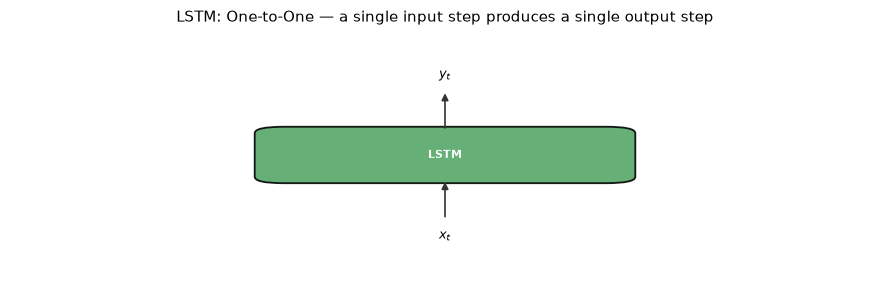

In [8]:
draw_rnn_typology(
    pattern=[(True, True)],
    title="LSTM: One-to-One — a single input step produces a single output step",
    cell_label="LSTM",
)

In [9]:
X1, y1 = make_one_to_one(train_scaled)
Xv1, yv1 = make_one_to_one(val_scaled)
print("X shape:", X1.shape, " y shape:", y1.shape)

model_one_to_one = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, N_FEATURES)),
    tf.keras.layers.LSTM(UNITS, return_sequences=True),
    tf.keras.layers.LSTM(UNITS, return_sequences=False),
    tf.keras.layers.Dense(1),
], name="lstm_one_to_one")

model_one_to_one.summary()
show_model_diagram(model_one_to_one, "lstm_one_to_one.png")

X shape: (24543, 1, 5)  y shape: (24543, 1)


E0000 00:00:1791088925.739016   99017 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "lstm_one_to_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 32)          │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,217 (51.63 KB)

 Trainable params: 13,217 (51.63 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


one_to_one: ran 100/100 epochs  final val_loss=0.00160  val_mae=0.02738  params=13,217


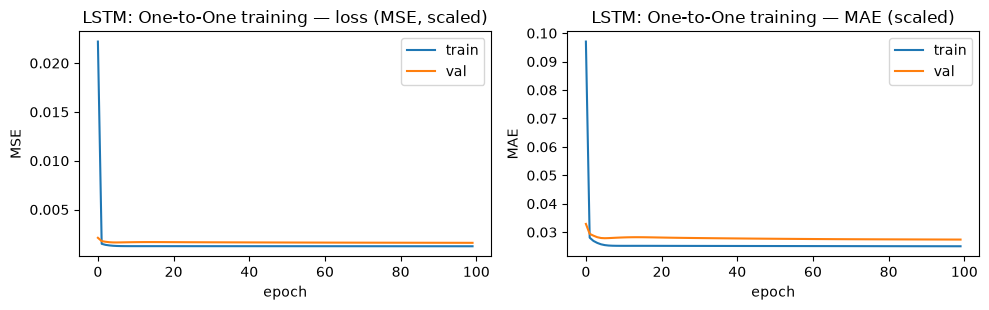

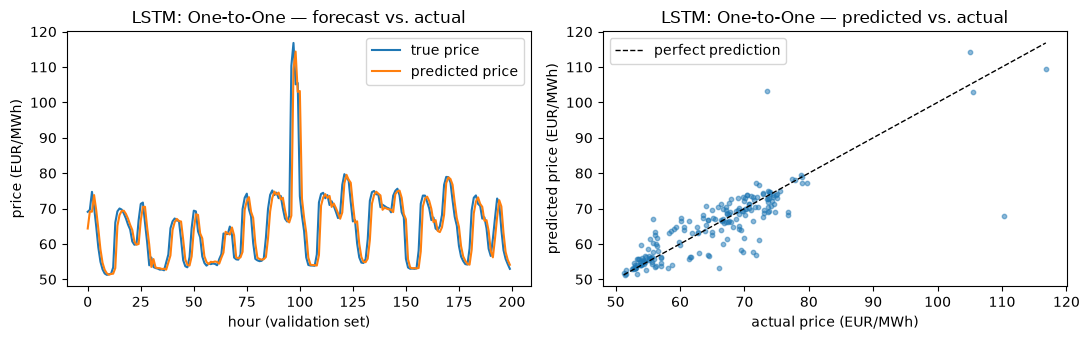

In [10]:
hist_1to1 = compile_and_fit(model_one_to_one, "one_to_one", X1, y1, Xv1, yv1)
plot_history(hist_1to1, "LSTM: One-to-One training")

pred = model_one_to_one.predict(Xv1, verbose=0)
plot_point_prediction(yv1, pred, "LSTM: One-to-One")

## 6. Architecture Type B — Many-to-One

`return_sequences=False` (the Keras default): the LSTM layer consumes
the full `WINDOW`-hour window and only its **final** hidden state is passed to the
Dense output layer. This is the classic setup for "predict the next value from
recent history" — e.g. tomorrow's price from the last 24 hours of load/generation/price.

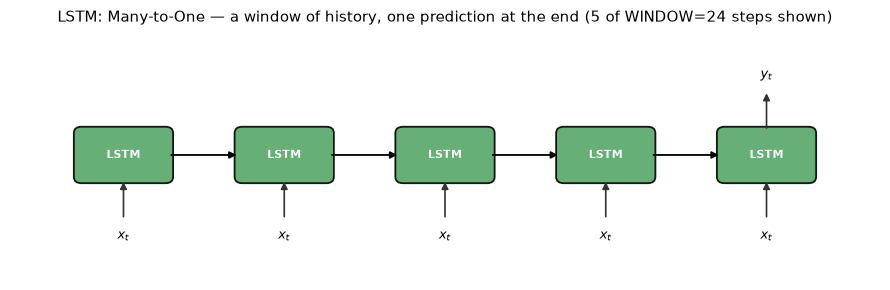

In [11]:
draw_rnn_typology(
    pattern=[(True, False)] * 4 + [(True, True)],
    title=f"LSTM: Many-to-One — a window of history, one prediction at the end (5 of WINDOW={WINDOW} steps shown)",
    cell_label="LSTM",
)

In [12]:
Xm1, ym1 = make_many_to_one(train_scaled, window=WINDOW)
Xv_m1, yv_m1 = make_many_to_one(val_scaled, window=WINDOW)
print("X shape:", Xm1.shape, " y shape:", ym1.shape)

model_many_to_one = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.LSTM(UNITS, return_sequences=True),
    tf.keras.layers.LSTM(UNITS, return_sequences=False),
    tf.keras.layers.Dense(1),
], name="lstm_many_to_one")

model_many_to_one.summary()
show_model_diagram(model_many_to_one, "lstm_many_to_one.png")

X shape: (24520, 24, 5)  y shape: (24520, 1)


Model: "lstm_many_to_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 32)         │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,217 (51.63 KB)

 Trainable params: 13,217 (51.63 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_one: ran 100/100 epochs  final val_loss=0.00078  val_mae=0.01927  params=13,217


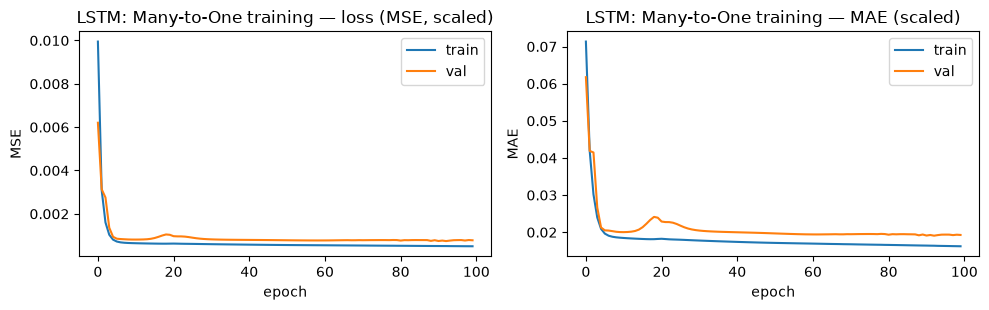

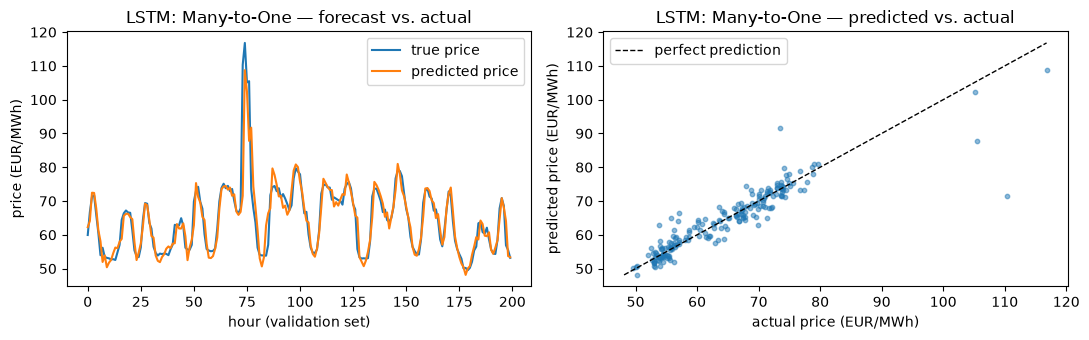

In [13]:
hist_m21 = compile_and_fit(model_many_to_one, "many_to_one", Xm1, ym1, Xv_m1, yv_m1)
plot_history(hist_m21, "LSTM: Many-to-One training")

pred = model_many_to_one.predict(Xv_m1, verbose=0)
plot_point_prediction(yv_m1, pred, "LSTM: Many-to-One")

## 7. Architecture Type C — One-to-Many

A single timestep is encoded into a hidden state, `RepeatVector(OUT_LEN)` copies that
state to seed every step of a *second* LSTM layer (`return_sequences=True`),
and `TimeDistributed(Dense(1))` applies the same output projection independently at
every generated step. This turns one snapshot into a generated sequence — e.g. one
hour's conditions kicking off a `{OUT_LEN}`-hour price forecast run, or (more classically)
one image feature vector generating a caption word-by-word.

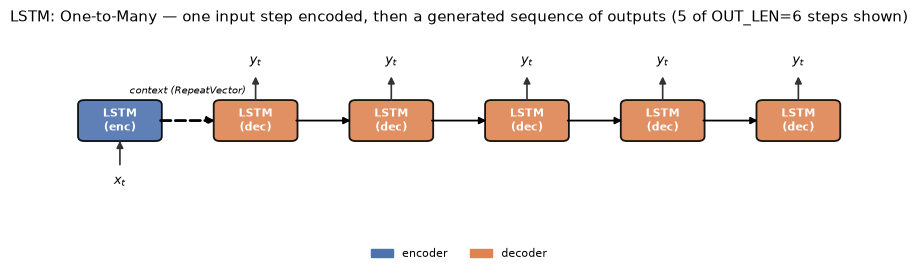

In [14]:
draw_rnn_typology(
    pattern=[(True, False)] + [(False, True)] * 5,
    title=f"LSTM: One-to-Many — one input step encoded, then a generated sequence of outputs (5 of OUT_LEN={OUT_LEN} steps shown)",
    cell_label="LSTM",
    encoder_decoder=True,
    split=1,
    context_label="context (RepeatVector)",
)

In [15]:
Xo, yo = make_one_to_many(train_scaled, out_len=OUT_LEN)
Xv_o, yv_o = make_one_to_many(val_scaled, out_len=OUT_LEN)
print("X shape:", Xo.shape, " y shape:", yo.shape)

model_one_to_many = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, N_FEATURES)),
    tf.keras.layers.LSTM(UNITS, return_sequences=True),   # encoder
    tf.keras.layers.LSTM(UNITS, return_sequences=False),  # 2nd encoder layer
    tf.keras.layers.RepeatVector(OUT_LEN),
    tf.keras.layers.LSTM(UNITS, return_sequences=True),    # decoder
    tf.keras.layers.LSTM(UNITS, return_sequences=True),   # 2nd decoder layer
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="lstm_one_to_many")

model_one_to_many.summary()
show_model_diagram(model_one_to_many, "lstm_one_to_many.png")

X shape: (24537, 1, 5)  y shape: (24537, 6, 1)


Model: "lstm_one_to_many"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 1, 32)          │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 6, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 6, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


In [ ]:
hist_1tm = compile_and_fit(model_one_to_many, "one_to_many", Xo, yo, Xv_o, yv_o)
plot_history(hist_1tm, "LSTM: One-to-Many training")

pred = model_one_to_many.predict(Xv_o[:8], verbose=0)
plot_sequence_prediction(yv_o[:8], pred, f"LSTM: One-to-Many — generated {OUT_LEN}-hour runs")

## 8. Architecture Type D — Many-to-Many (Synced)

`return_sequences=True` on a *single* LSTM layer, wrapped by
`TimeDistributed(Dense(1))`: the network emits one prediction **per input timestep**,
aligned in lockstep with the input (output length == input length). This is the shape
used for per-timestep sequence labeling tasks (POS tagging, per-frame classification)
— here, predicting the next hour's price at every position of a sliding window,
rather than only at the end as Many-to-One does.

In [ ]:
draw_rnn_typology(
    pattern=[(True, True)] * 5,
    title=f"LSTM: Many-to-Many (synced) — one aligned output per input step (5 of WINDOW={WINDOW} steps shown)",
    cell_label="LSTM",
)

In [ ]:
Xs, ys = make_synced_many_to_many(train_scaled, window=WINDOW)
Xv_s, yv_s = make_synced_many_to_many(val_scaled, window=WINDOW)
print("X shape:", Xs.shape, " y shape:", ys.shape)

model_synced = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.LSTM(UNITS, return_sequences=True),
    tf.keras.layers.LSTM(UNITS, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="lstm_synced_many_to_many")

model_synced.summary()
show_model_diagram(model_synced, "lstm_synced_many_to_many.png")

In [ ]:
hist_sync = compile_and_fit(model_synced, "many_to_many_synced", Xs, ys, Xv_s, yv_s)
plot_history(hist_sync, "LSTM: Many-to-Many (synced) training")

pred = model_synced.predict(Xv_s[:8], verbose=0)
plot_sequence_prediction(yv_s[:8], pred, "LSTM: Many-to-Many (synced) — per-step predictions")

## 9. Architecture Type E — Many-to-Many (Encoder–Decoder / Seq2Seq)

The general many-to-many case, where input length and output length can differ
(`IN_WINDOW={WINDOW}` hours in, `OUT_HORIZON={OUT_LEN}` hours out). An **encoder**
LSTM compresses the input window into a single context vector
(`return_sequences=False`); `RepeatVector` seeds a **decoder** LSTM
(`return_sequences=True`); `TimeDistributed(Dense(1))` projects each decoder step to
a prediction. This is the same encoder-decoder pattern used for machine translation
and multi-step time-series forecasting — the "sequence in, differently-sized
sequence out" case that Many-to-One and the synced Many-to-Many above can't express.

In [ ]:
draw_rnn_typology(
    pattern=[(True, False)] * 4 + [(False, True)] * 3,
    title=f"LSTM: Many-to-Many (seq2seq) — an encoder window in, a differently-sized decoder window out (4 of WINDOW={WINDOW} + 3 of OUT_HORIZON={OUT_LEN} steps shown)",
    cell_label="LSTM",
    encoder_decoder=True,
    split=4,
    context_label="context vector",
)

In [ ]:
Xe, ye = make_seq2seq(train_scaled, in_window=WINDOW, out_horizon=OUT_LEN)
Xv_e, yv_e = make_seq2seq(val_scaled, in_window=WINDOW, out_horizon=OUT_LEN)
print("X shape:", Xe.shape, " y shape:", ye.shape)

model_seq2seq = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.LSTM(UNITS, return_sequences=True),   # encoder
    tf.keras.layers.LSTM(UNITS, return_sequences=False),  # 2nd encoder layer
    tf.keras.layers.RepeatVector(OUT_LEN),
    tf.keras.layers.LSTM(UNITS, return_sequences=True),    # decoder
    tf.keras.layers.LSTM(UNITS, return_sequences=True),   # 2nd decoder layer
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="lstm_seq2seq")

model_seq2seq.summary()
show_model_diagram(model_seq2seq, "lstm_seq2seq.png")

In [ ]:
hist_s2s = compile_and_fit(model_seq2seq, "many_to_many_seq2seq", Xe, ye, Xv_e, yv_e)
plot_history(hist_s2s, "LSTM: Many-to-Many (seq2seq) training")

pred = model_seq2seq.predict(Xv_e[:8], verbose=0)
plot_sequence_prediction(yv_e[:8], pred, f"LSTM: Many-to-Many (seq2seq) — {WINDOW}h -> {OUT_LEN}h forecast")

## 10. Summary & Comparison

Recap of the five typologies built above, all using the same **LSTM** cell:

| Type | Input shape | Output shape | `return_sequences` pattern | Example use here |
|---|---|---|---|---|
| One-to-one | `(1, features)` | `(1,)` | n/a (single step) | next-hour price from this hour only |
| Many-to-one | `(window, features)` | `(1,)` | `False` | next-hour price from last 24h |
| One-to-many | `(1, features)` | `(out_len, 1)` | encoder `False`, decoder `True` | generate a {OUT_LEN}-hour forecast from one snapshot |
| Many-to-many (synced) | `(window, features)` | `(window, 1)` | `True` | per-step next-value prediction |
| Many-to-many (seq2seq) | `(in_window, features)` | `(out_horizon, 1)` | encoder `False`, decoder `True` | {WINDOW}h history -> {OUT_LEN}h forecast |

The cell below tabulates trained parameter counts and final validation loss/MAE for
every architecture in this notebook, so you can see how model size scales with the
task shape even though the underlying LSTM cell is identical throughout.

In [ ]:
rows = []
for name, model in [
    ("one_to_one", model_one_to_one),
    ("many_to_one", model_many_to_one),
    ("one_to_many", model_one_to_many),
    ("many_to_many_synced", model_synced),
    ("many_to_many_seq2seq", model_seq2seq),
]:
    h = history_log[name]
    rows.append({
        "architecture": name,
        "params": model.count_params(),
        "final_val_loss_mse": h.history["val_loss"][-1],
        "final_val_mae": h.history["val_mae"][-1],
    })

summary_df = pd.DataFrame(rows).set_index("architecture")
summary_df

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
summary_df["params"].plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Trainable parameters by architecture")
axes[0].set_ylabel("parameters")
axes[0].tick_params(axis="x", rotation=30)

summary_df["final_val_mae"].plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_title("Final validation MAE (scaled) by architecture")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## References & Notes

- Dataset: Nicholas J. Hana, *Hourly Energy Demand Generation and Weather*, Kaggle
  (`nicholasjhana/energy-consumption-generation-prices-and-weather`).
- Hochreiter & Schmidhuber (1997), *Long Short-Term Memory*, Neural Computation 9(8).
- Cho et al. (2014), *Learning Phrase Representations using RNN Encoder-Decoder for
  Statistical Machine Translation* (introduces the GRU).
- Karpathy, *The Unreasonable Effectiveness of Recurrent Neural Networks* — the
  original source of the one-to-one / one-to-many / many-to-one / many-to-many
  diagram this notebook implements in code.

**Each LSTM cell carries roughly 4x the parameters of a same-sized vanilla RNN cell (one set of weights per gate + candidate) — check the parameter counts in the comparison section at the end.**

**Companion notebooks:** the other two files in this set repeat every architecture
above with the same data pipeline, swapping only the recurrent cell
(`SimpleRNN` / `LSTM` / `GRU`) — use them side by side to compare parameter counts,
training curves, and forecast quality across cell types on identical tasks.

## Test performance of the stacked LSTM models

Run the cells above first. This section evaluates the newly trained models on the held-out chronological test split. MAE and RMSE are in EUR/MWh; MSE is in squared EUR/MWh. Lower MAE, MSE, and RMSE and higher R² indicate better predictions **for the same forecasting task**.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true_scaled, y_pred_scaled):
    y_true = inverse_target(np.asarray(y_true_scaled)).reshape(-1)
    y_pred = inverse_target(np.asarray(y_pred_scaled)).reshape(-1)
    mse = mean_squared_error(y_true, y_pred)
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "MSE": mse, "RMSE": np.sqrt(mse),
            "R2": r2_score(y_true, y_pred)}

test_pairs = {
    "one_to_one": (model_one_to_one, *make_one_to_one(test_scaled)),
    "many_to_one": (model_many_to_one, *make_many_to_one(test_scaled, window=WINDOW)),
    "one_to_many": (model_one_to_many, *make_one_to_many(test_scaled, out_len=OUT_LEN)),
    "many_to_many_synced": (model_synced, *make_synced_many_to_many(test_scaled, window=WINDOW)),
    "many_to_many_seq2seq": (model_seq2seq, *make_seq2seq(test_scaled, in_window=WINDOW, out_horizon=OUT_LEN)),
}

test_rows = []
for typology, (model, X_test, y_test) in test_pairs.items():
    predictions = model.predict(X_test, verbose=0)
    test_rows.append({"typology": typology,
                      "parameters": model.count_params(),
                      **regression_metrics(y_test, predictions)})
test_metrics_df = pd.DataFrame(test_rows).set_index("typology")
display(test_metrics_df.round(4))


## Interpreting the LSTM typology results

The next cell identifies the lowest test RMSE in this run and reports the other metrics for that layout. It also shows each layout's score relative to its own test results. One-to-one, many-to-one, one-to-many, synchronized many-to-many, and sequence-to-sequence forecast different numbers and positions of prices, so a ranking across these layouts is **descriptive**, not evidence that one architecture is universally superior. Compare LSTM with RNN and GRU only when the typology and test data match.


In [ ]:
ranked = test_metrics_df.sort_values("RMSE")
display(ranked.round(4))
winner = ranked.iloc[0]
print(f"Lowest RMSE in this notebook: {ranked.index[0]} "
      f"(MAE={winner['MAE']:.4f}, MSE={winner['MSE']:.4f}, "
      f"RMSE={winner['RMSE']:.4f}, R²={winner['R2']:.4f}).")
print("Interpretation: this is the lowest measured test error among this model's "
      "five forecasting layouts. Their prediction horizons and targets differ; "
      "use matching layouts for a fair model-to-model comparison.")
